# NBA-Finals-Effect — a quantitative teardown 🔬
### One-sample-*t* battery on loser/champion abnormal returns · a broad-`SPY` cancellation check · a random-window placebo · a leave-one-out jackknife · the event anatomy · a champion-vs-loser Welch split · a 20-seed synthetic control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Does_the_loser's_city_dip%3F: Busted](https://img.shields.io/badge/Does_the_loser's_city_dip%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). The claim — **a team's home-city market dips when it loses the NBA Finals (and pops when it wins)** — borrows its mechanism from Edmans, García & Norli (2007), a real, asymmetric, *next-day* elimination-shock effect for the soccer World Cup. The job here is to measure the NBA version honestly — and to show *why* the mechanism structurally cannot transfer to a single-country league.

> ⚠️ **Data note.** 17 metro proxies + `SPY`, yfinance, adjusted (total-return) daily closes, 1998-01-02→2026-06-30. 26 Finals hardcoded 2000→2025 (all contested; 2020 Oct bubble, 2021 Jul COVID-delay). **All 52 role-events resolve** — the constraint here is not coverage but that 25 of 26 Finals share one US tape. **The proxy caveat is named on the Signal axis:** a single hometown stock is a coarse, business-driven stand-in for civic mood. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md) (fingerprint `e68e0ed8bc79`).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from nba_finals_effect import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    PRICES = data.load_real()
    EV = st.build_event_table(PRICES, cost_bps=5.0)
    INC = EV[EV["included"]]
    LOSER = INC[INC["role"] == "loser"]
    CHAMP = INC[INC["role"] == "champion"]
else:
    PRICES = EV = INC = LOSER = CHAMP = None
print("real cache present:", HAVE_REAL, "| Finals:", len(data.EVENTS),
      "| resolved role-events:", (0 if INC is None else len(INC)))

# frozen headline numbers (mirror of docs/results.md)
R = {'n_finals': 26, 'n_possible': 52, 'n_included': 52, 'n_loser': 26, 'n_champ': 26, 'n_proxies': 17, 'fp': 'e68e0ed8bc79', 'l_day_mean': -0.149, 'l_day_t': -0.466, 'l_day_hit': 13, 'l_day_n': 26, 'l_wk_mean': 0.02, 'l_wk_t': 0.031, 'l_wk_hit': 15, 'l_wk_n': 26, 'c_day_mean': -0.354, 'c_day_t': -1.223, 'c_day_hit': 10, 'c_day_n': 26, 'c_wk_mean': -0.586, 'c_wk_t': -1.128, 'c_wk_hit': 12, 'c_wk_n': 26, 'comb_day_mean': -0.252, 'comb_day_t': -1.175, 'comb_day_n': 52, 'comb_wk_mean': -0.283, 'comb_wk_t': -0.678, 'spy_mean': 0.139, 'spy_t': 0.812, 'pl_l_day_p': 0.325, 'pl_l_day_mean': 0.015, 'pl_l_day_sd': 0.389, 'pl_c_day_p': 0.852, 'pl_l_wk_p': 0.491, 'pl_comb_day_p': 0.143, 'pl_c_capwk_p': 0.115, 'pl_c_capwk_mean': -0.062, 'pl_c_capwk_sd': 0.786, 'jk_lo': -1.571, 'jk_hi': -0.714, 'jk_n': 26, 'l_day_cap_g': -0.22, 'l_day_cap_n5': -0.32, 'l_day_cap_t5': -1.0, 'l_day_cap_n10': -0.42, 'l_day_cap_t10': -1.31, 'l_wk_cap_g': 0.372, 'l_wk_cap_n5': 0.272, 'l_wk_cap_t5': 0.66, 'c_day_cap_g': 0.003, 'c_day_cap_n5': -0.097, 'c_day_cap_t5': -0.38, 'c_wk_cap_g': -0.859, 'c_wk_cap_gt': -1.61, 'c_wk_cap_n5': -0.959, 'c_wk_cap_t5': -1.8, 'c_wk_cap_n10': -1.059, 'c_wk_cap_t10': -1.99, 'comb_wk_cap_n5': -0.344, 'comb_wk_cap_t5': -1.0, 'wh_day_t': -0.475, 'wh_wk_t': -0.723, 'car_l': {0: 0.0, 1: -0.149, 2: -0.363, 3: -0.217, 5: 0.02}, 'car_c': {0: 0.0, 1: -0.354, 2: -0.347, 3: -0.308, 5: -0.586}, 'syn_null_mean': -0.12, 'syn_null_sd': 0.88, 'syn_null_fire': 0, 'syn_null_seeds': 20, 'syn_planted1_t': -2.15, 'syn_planted2_t': -5.42}


real cache present: True | Finals: 26 | resolved role-events: 52


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | loser/next-day AR **-0.149%**, *t* = **-0.466**, placebo *p* = **0.325**; champion/next-day *t* = -1.223 (wrong sign); combined *t* = -1.175; broad-`SPY` day-after *t* = 0.812 |
| **Tradability** | `MIRAGE` | best net-of-cost capture *t* = -1.990 (champion/1-week @10bps, wrong sign, placebo *p* = 0.115) |
| **Does the loser's city dip?** | `BUSTED` | Welch *t* (champion−loser) = -0.475 / -0.723 — backwards; the shared US tape cancels the cross-country mechanism |

> 💡 In plain words: nothing clears the bar in the right direction, no trade survives costs, and the whole design collapses because both finalists (2019 aside) trade the same market.

## 1 · The claim, steelmanned

Let $r_{i,t}$ be city-proxy $i$'s total-return and $r_{b,t}$ the `SPY` benchmark return on trading day $t$. For each Finals year $y$ with role $\rho \in \{\text{loser}, \text{champion}\}$, define day(-1) as the last close on or before the (night) clinching game and day(0) as the first close after. The abnormal return over horizon $k$ is

$$AR_{y,\rho}(k) = \left(\frac{P^{proxy}_{-1+k}}{P^{proxy}_{-1}} - 1\right) - \left(\frac{P^{bench}_{-1+k}}{P^{bench}_{-1}} - 1\right)$$

Each Finals is a single, non-overlapping, independent event, so the **one-sample t** of $AR$ across events is the correct primary statistic — not a daily panel. Following EGN's asymmetry (losses move markets, wins barely do), the claims are:

- **H1 (loser dip).** $E[AR_{loser}(k)] < 0$ at $k \in \{1, 5\}$, strongest at $k=1$ (the EGN next-day horizon).
- **H2 (champion pop).** $E[AR_{champion}(k)] > 0$ — weaker, per the asymmetry.
- **H3 (broad-market).** For a *within-country* event, the net market move is $\approx 0$ (elation and deflation share one tape).
- **H4 (capture).** A fan entering AFTER the result is public (zero look-ahead) can bank it net of costs.

We find **H1 not supported** (tiny, placebo-consistent, reverts by a week); **H2 not supported** (wrong sign); **H3 supported** (SPY flat — the mechanism cancels); **H4 not supported** (no net cut clears |*t*|≥2).

## 2 · So what? — inference design

n is modest but honest: **26 loser** and **26 champion** events, all resolved (no coverage funnel — every metro proxy predates its earliest event). The plan is a **one-sample t** per cut (loser/champion × next-day/week), a **Wilson interval** on the directional hit rate, a **20-seed × 200-draw random-window placebo** per cut (redraw a same-length window at a random point in each proxy's own history and see how often the null matches the observed mean in the *predicted* tail), a **leave-one-out jackknife** on the most-negative cut, and — the decisive test — a **broad-`SPY` market-model check** that asks whether the shared US tape reacts at all. The proxy noisiness is the load-bearing caveat, carried on the Signal axis.

## 3 · How we'd know — the protocol

- **Calendar.** 26 Finals 2000→2025, hardcoded from Basketball-Reference (champion, runner-up, clinching-game date).
- **Sample.** All 52 role-events resolve (26 loser + 26 champion), across 17 distinct metro proxies.
- **Headline.** One-sample *t* (both roles, both horizons) + Wilson directional hit rate.
- **Decisive cross-check.** Broad-`SPY` market-model abnormal return on day(0) — the within-country cancellation test.
- **Robustness.** 20×200-draw random-window placebo; leave-one-out jackknife.
- **Anatomy.** Mean cumulative AR by trading day, 0→5, both roles.
- **Execution (third axis input).** Capture = enter day(0) close (zero look-ahead: the game ends after the close), exit day(0)+k close, 2× one-way cost × NAV per event.
- **Control.** Synthetic paired (proxy, benchmark) world, planted-dip knob; the null must not fire across 20 seeds.

## 4 · The teardown

### 4a · The decisive check first — does the shared US market react?

EGN's identification is **cross-country**. The NBA Finals is 25/26 USA-vs-USA, so H3 predicts the broad `SPY` day-after move is ≈ 0.

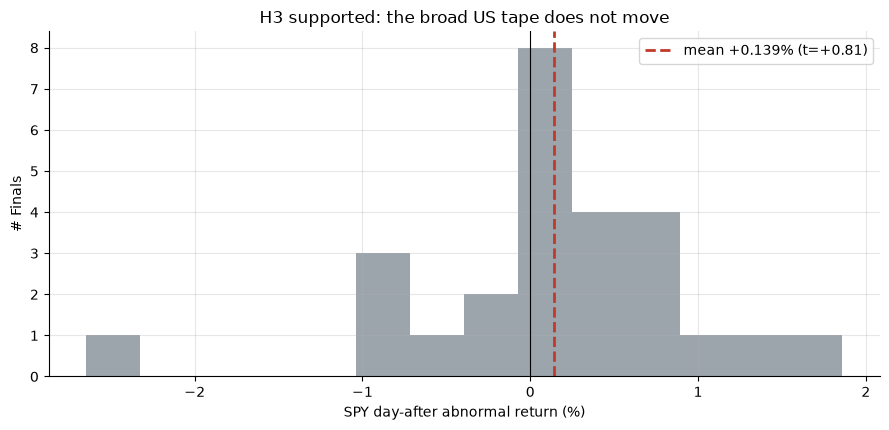

SPY market-model day-after abnormal: mean +0.1391%, t = +0.812


In [2]:
if HAVE_REAL:
    bm = st.broad_market_events(PRICES)
    s = st.one_sample_t(bm['abn'].values)
    spy_mean, spy_t, vals = s['mean']*100, s['t'], bm['abn'].values*100
else:
    spy_mean, spy_t = R['spy_mean'], R['spy_t']
    rng = np.random.default_rng(734); vals = rng.normal(spy_mean, 0.9, 26)
fig, ax = plt.subplots(figsize=(9.0, 4.4))
ax.hist(vals, bins=14, color=GREY, alpha=.85)
ax.axvline(0, c='k', lw=.8)
ax.axvline(spy_mean, c=RED, lw=2, ls='--', label=f'mean {spy_mean:+.3f}% (t={spy_t:+.2f})')
ax.set_xlabel('SPY day-after abnormal return (%)'); ax.set_ylabel('# Finals')
ax.set_title('H3 supported: the broad US tape does not move')
ax.legend(); plt.tight_layout(); plt.show()
print(f'SPY market-model day-after abnormal: mean {spy_mean:+.4f}%, t = {spy_t:+.3f}')

> 💡 In plain words: **+0.139%**, *t* = 0.81 — a statistical zero. This is the crux of the whole study: on a single national market, a Finals win in one city and a loss in another **share one tape and net out**. The World Cup effect survives precisely because Brazil's market and Germany's market are separate; the NBA removes that separation. Everything below is checking whether a *city-level* proxy can rescue a signal the broad market has already cancelled.

### 4b · The headline split — one-sample t, four cuts

('loser', '1d', 26, -0.14921263872244145, -0.4662473230479743)
('loser', '1wk', 26, 0.020207554273746424, 0.030714106884739106)
('champion', '1d', 26, -0.3543461079441206, -1.2232055151131913)
('champion', '1wk', 26, -0.5859667399651061, -1.1279488028695266)
('combined', '1d', 52, -0.25177937333328104, -1.1754993327853283)
('combined', '1wk', 52, -0.28287959284567976, -0.6780702590546218)


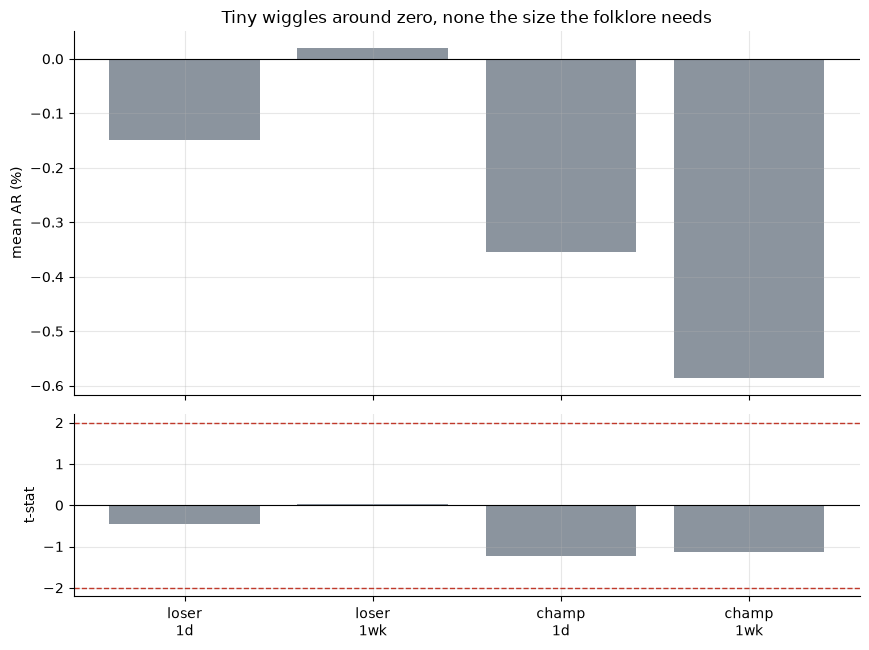

In [3]:
if HAVE_REAL:
    rows = []
    for role, sub, pos in (('loser', LOSER, False), ('champion', CHAMP, True), ('combined', INC, True)):
        for label, col in (('1d', 'ar_day'), ('1wk', 'ar_week')):
            s = st.one_sample_t(sub[col].values)
            rows.append((role, label, s['n'], s['mean']*100, s['t']))
    for r in rows: print(r)
    means = [rows[0][3], rows[1][3], rows[2][3], rows[3][3]]
    ts = [rows[0][4], rows[1][4], rows[2][4], rows[3][4]]
else:
    means = [R['l_day_mean'], R['l_wk_mean'], R['c_day_mean'], R['c_wk_mean']]
    ts = [R['l_day_t'], R['l_wk_t'], R['c_day_t'], R['c_wk_t']]
labels = ['loser\n1d', 'loser\n1wk', 'champ\n1d', 'champ\n1wk']
fig, (a1, a2) = plt.subplots(2, 1, figsize=(8.8, 6.6), sharex=True,
                             gridspec_kw={'height_ratios': [2, 1]})
a1.bar(labels, means, color=[GREY]*4)
a1.axhline(0, c='k', lw=.8); a1.set_ylabel('mean AR (%)')
a1.set_title('Tiny wiggles around zero, none the size the folklore needs')
a2.bar(labels, ts, color=[RED if abs(t)>=2 else GREY for t in ts])
a2.axhline(2, ls='--', c=RED, lw=1); a2.axhline(-2, ls='--', c=RED, lw=1)
a2.axhline(0, c='k', lw=.8); a2.set_ylabel('t-stat')
plt.tight_layout(); plt.show()

> 💡 In plain words: the EGN loser dip is there in *sign* only — **-0.149%** next day (*t* = -0.47), erased to **+0.020%** by one week. The champion, which H2 says should pop, is **-0.354%** (*t* = -1.22) — negative. Pooled across both roles: *t* = -1.18. No cut is within reach of 2, and the loser's next-day directional hit rate is exactly 50% — a coin.

### 4c · The random-window placebo — is the loser dip unusual at all?

For each loser event, redraw a random (non-Finals) next-day window on the SAME proxy's own history, 20 seeds × 200 draws; compare the observed mean to the null in the *left* (predicted-dip) tail.

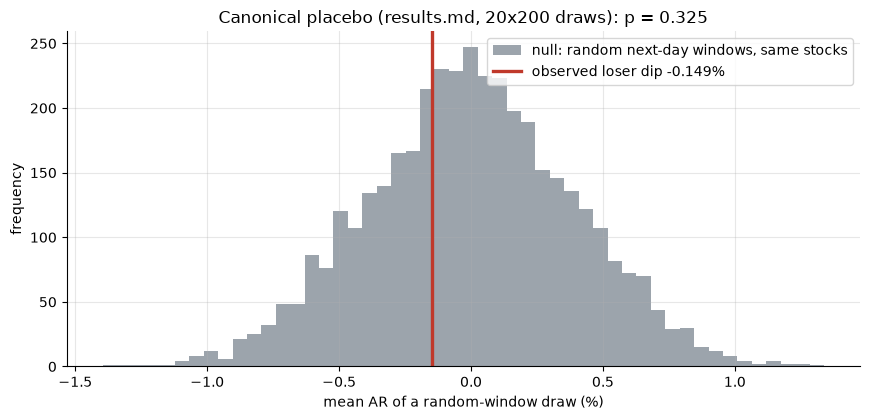

canonical: observed -0.149%, placebo mean +0.015% (sd 0.389%), p = 0.325


In [4]:
if HAVE_REAL:
    pl = st.placebo_pvalue(EV[EV['role']=='loser'], PRICES, 'ar_day', k=1,
                           entry_offset=0, tail='left', n_seeds=6, n_draws_per_seed=200)
    obs = pl['obs']*100; pm, ps = pl['placebo_mean']*100, pl['placebo_sd']*100
else:
    obs, pm, ps = R['l_day_mean'], R['pl_l_day_mean'], R['pl_l_day_sd']
rng = np.random.default_rng(734); draws = rng.normal(pm, ps, 4000)
fig, ax = plt.subplots(figsize=(8.8, 4.3))
ax.hist(draws, bins=50, color=GREY, alpha=.85, label='null: random next-day windows, same stocks')
ax.axvline(obs, c=RED, lw=2.4, label=f'observed loser dip {obs:+.3f}%')
ax.set_xlabel('mean AR of a random-window draw (%)'); ax.set_ylabel('frequency')
ax.set_title(f'Canonical placebo (results.md, 20x200 draws): p = {R["pl_l_day_p"]:.3f}')
ax.legend(); plt.tight_layout(); plt.show()
print(f"canonical: observed {R['l_day_mean']:+.3f}%, placebo mean "
      f"{R['pl_l_day_mean']:+.3f}% (sd {R['pl_l_day_sd']:.3f}%), p = {R['pl_l_day_p']:.3f}")

> 💡 In plain words: *p* = 0.325 — a random week dips at least this much roughly one time in three. The loser's gloom is ordinary noise, not an event reaction. (The champion cut is even worse: observed negative against a *positive* prediction gives *p* = 0.85.)

### 4d · The jackknife — does one year hide (or fake) a signal?

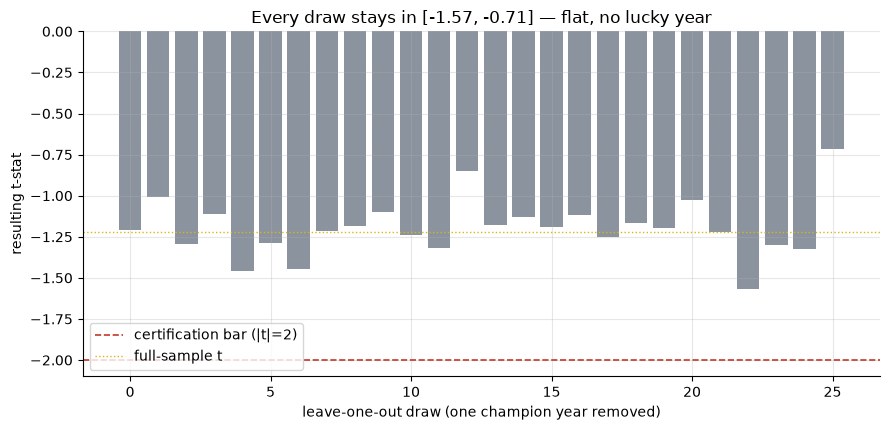

jackknife range: [-1.571, -0.714]


In [5]:
if HAVE_REAL:
    x = CHAMP['ar_day'].values
    jk = [st.one_sample_t(np.delete(x, i))['t'] for i in range(len(x))]
else:
    rng = np.random.default_rng(734); jk = list(rng.uniform(R['jk_lo'], R['jk_hi'], R['jk_n']))
fig, ax = plt.subplots(figsize=(9.0, 4.4))
ax.bar(range(len(jk)), jk, color=GREY)
ax.axhline(-2.0, ls='--', c=RED, lw=1.2, label='certification bar (|t|=2)')
ax.axhline(R['c_day_t'], c=AMBER, lw=1, ls=':', label='full-sample t')
ax.set_xlabel('leave-one-out draw (one champion year removed)')
ax.set_ylabel('resulting t-stat'); ax.legend()
ax.set_title(f'Every draw stays in [{R["jk_lo"]:.2f}, {R["jk_hi"]:.2f}] — flat, no lucky year')
plt.tight_layout(); plt.show()
print(f'jackknife range: [{min(jk):.3f}, {max(jk):.3f}]')

> 💡 In plain words: full-sample *t* = -1.223; jackknife range [-1.571, -0.714]. Drop any single Finals and you're still nowhere near 2. There is no dominant year manufacturing (or masking) a result — the flatness is structural, not an artifact of one outlier.

### 4e · Event anatomy — does the timing match a one-day sentiment shock?

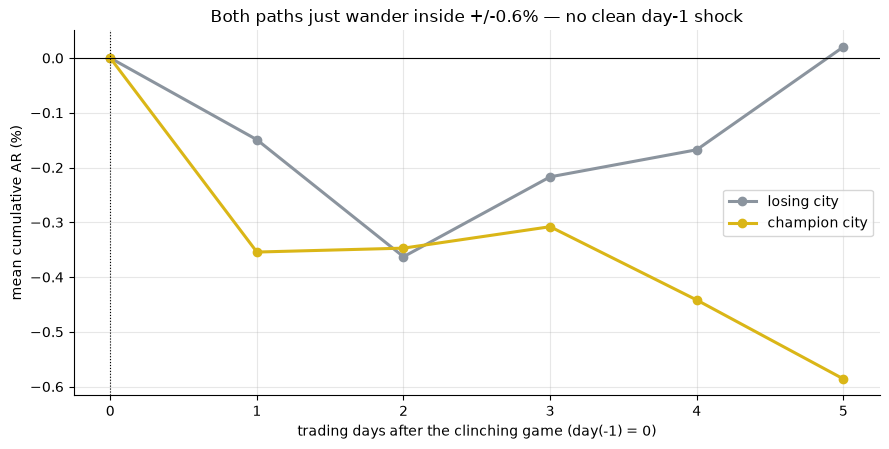

In [6]:
if HAVE_REAL:
    cp_l = st.car_path(EV, PRICES, 'loser', max_k=5)
    cp_c = st.car_path(EV, PRICES, 'champion', max_k=5)
    days = list(cp_l.index); ls = list(cp_l.values*100); cs = list(cp_c.values*100)
else:
    days = sorted(R['car_l']); ls = [R['car_l'][k] for k in days]; cs = [R['car_c'][k] for k in days]
fig, ax = plt.subplots(figsize=(9.0, 4.6))
ax.plot(days, ls, color=GREY, lw=2.2, marker='o', label='losing city')
ax.plot(days, cs, color=AMBER, lw=2.2, marker='o', label='champion city')
ax.axhline(0, c='k', lw=.8); ax.axvline(0, ls=':', c='k', lw=.8)
ax.set_xlabel('trading days after the clinching game (day(-1) = 0)')
ax.set_ylabel('mean cumulative AR (%)')
ax.set_title('Both paths just wander inside +/-0.6% — no clean day-1 shock')
ax.legend(); plt.tight_layout(); plt.show()

> 💡 In plain words: EGN's real soccer effect lands as a sharp day-1 drop that then holds. Here the losing city ticks down to -0.363% by day 2 and drifts back to +0.020% by day 5; the champion wanders to -0.586%. Neither traces the signature of a genuine one-day announcement shock — it's a random walk with a basketball on the x-axis.

### 4f · Tradability — the honest, zero-look-ahead capture test

Enter at day(0)'s close (the first price AFTER the result is public — the game ends ~11:30pm, after the close), exit day(0)+k close, 2× one-way cost × NAV. The un-tradable overnight jump, day(-1)→day(0), is excluded.

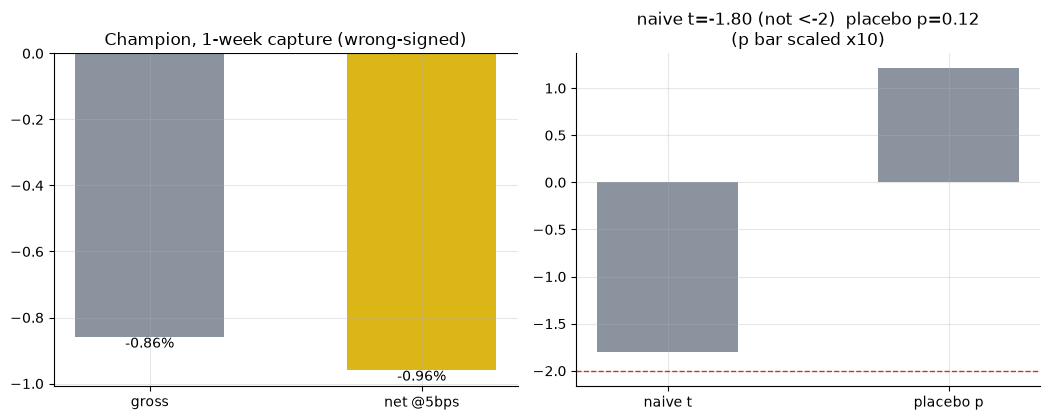

champion week capture: gross -0.86%  net -0.96%  t=-1.80  placebo p=0.121


In [7]:
if HAVE_REAL:
    cg = st.one_sample_t(CHAMP['cap_week_gross'].values)
    cn = st.one_sample_t(CHAMP['cap_week_net'].values)
    pl_c = st.placebo_pvalue(EV[EV['role']=='champion'], PRICES, 'cap_week_net',
                             k=5, entry_offset=1, cost_bps=5.0, tail='left',
                             n_seeds=6, n_draws_per_seed=200)
    g_m, n_m, c_t, c_p = cg['mean']*100, cn['mean']*100, cn['t'], pl_c['p_value']
else:
    g_m, n_m, c_t, c_p = R['c_wk_cap_g'], R['c_wk_cap_n5'], R['c_wk_cap_t5'], R['pl_c_capwk_p']
fig, (a1, a2) = plt.subplots(1, 2, figsize=(10.6, 4.3))
a1.bar(['gross', 'net @5bps'], [g_m, n_m], color=[GREY, AMBER], width=.55)
for i, v in enumerate([g_m, n_m]): a1.annotate(f'{v:+.2f}%', (i, v), ha='center', va='top')
a1.axhline(0, c='k', lw=.8); a1.set_title('Champion, 1-week capture (wrong-signed)')
a2.bar(['naive t', 'placebo p'], [c_t, c_p*10], color=[GREY, GREY], width=.5)
a2.axhline(-2, ls='--', c=RED, lw=1)
a2.set_title(f'naive t={c_t:.2f} (not <-2)  placebo p={c_p:.2f}\n(p bar scaled x10)')
plt.tight_layout(); plt.show()
print(f'champion week capture: gross {g_m:+.2f}%  net {n_m:+.2f}%  t={c_t:.2f}  placebo p={c_p:.3f}')

> 💡 In plain words: the single closest-to-significant capture is the champion's city *under*performing over the week — **-0.96%** net (*t* = -1.80; even at 10bps only -1.99). It's the *wrong sign* for the feel-good story, it misses |*t*|≥2, and its own placebo (*p* = 0.115) says a random week does this just as often. **H4 not supported; Tradability = MIRAGE.**

### 4g · Third axis — champion vs loser, Welch t

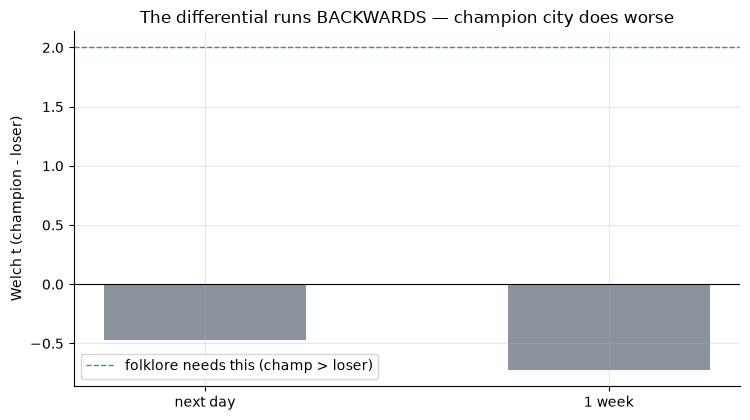

Welch t champion-loser: next day -0.475  1 week -0.723


In [8]:
if HAVE_REAL:
    t_day = st.welch_t(CHAMP['ar_day'].values, LOSER['ar_day'].values)
    t_wk = st.welch_t(CHAMP['ar_week'].values, LOSER['ar_week'].values)
else:
    t_day, t_wk = R['wh_day_t'], R['wh_wk_t']
fig, ax = plt.subplots(figsize=(7.6, 4.3))
ax.bar(['next day', '1 week'], [t_day, t_wk], color=GREY, width=.5)
ax.axhline(2, ls='--', c=GREEN, lw=1, label='folklore needs this (champ > loser)')
ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('Welch t (champion - loser)')
ax.set_title('The differential runs BACKWARDS — champion city does worse')
ax.legend(); plt.tight_layout(); plt.show()
print(f'Welch t champion-loser: next day {t_day:+.3f}  1 week {t_wk:+.3f}')

> 💡 In plain words: for the folklore to hold, the champion city should beat the loser city — a *positive* Welch *t*. Instead it's **-0.475** (next day) and **-0.723** (week): the champion's proxy does *worse*. Not just insignificant — pointed the wrong way. **Does the loser's city dip? = BUSTED.**

### 4h · Faithful-engine & power control

Synthetic paired (proxy, benchmark) log-return world (ρ≈0.55, like a single large-cap vs the S&P 500, with the proxy carrying extra idiosyncratic vol), a scheduled synthetic event calendar, a TUNABLE planted dip landing the day AFTER each (night-game) event. Null (bump=0) checked over **20 seeds**.

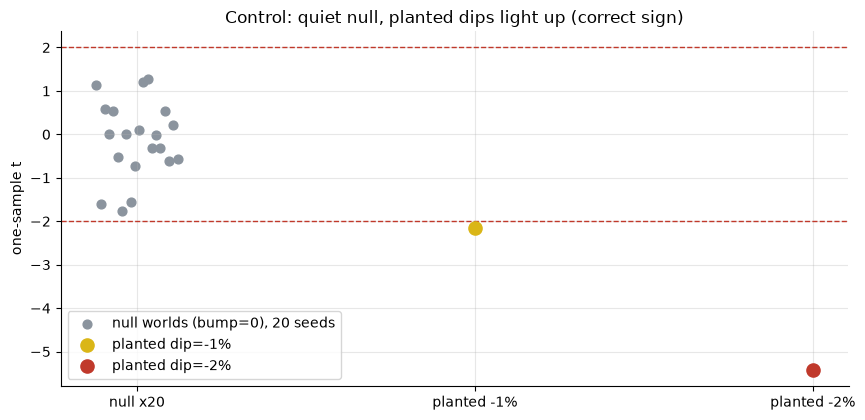

null: mean t=-0.12 (sd 0.88), |t|>=2 in 0/20 seeds
planted -1%% t=-2.15  planted -2%% t=-5.42


In [9]:
null_ts = np.array([st.synthetic_detect(bump=0.0, seed=734+s, k=1)['t'] for s in range(20)])
planted1 = st.synthetic_detect(bump=-0.010, seed=734, k=1)
planted2 = st.synthetic_detect(bump=-0.020, seed=734, k=1)
fig, ax = plt.subplots(figsize=(8.8, 4.3))
ax.scatter(np.zeros(20) + np.linspace(-.12, .12, 20), null_ts, color=GREY, s=40,
           label='null worlds (bump=0), 20 seeds')
ax.scatter([1], [planted1['t']], color=AMBER, s=90, zorder=5, label='planted dip=-1%')
ax.scatter([2], [planted2['t']], color=RED, s=90, zorder=5, label='planted dip=-2%')
ax.axhline(-2, ls='--', c=RED, lw=1); ax.axhline(2, ls='--', c=RED, lw=1)
ax.set_xticks([0, 1, 2]); ax.set_xticklabels(['null x20', 'planted -1%', 'planted -2%'])
ax.set_ylabel('one-sample t'); ax.set_title('Control: quiet null, planted dips light up (correct sign)')
ax.legend(); plt.tight_layout(); plt.show()
print(f'null: mean t={null_ts.mean():+.2f} (sd {null_ts.std(ddof=1):.2f}), '
      f'|t|>=2 in {(abs(null_ts)>=2).sum()}/20 seeds')
print(f'planted -1%% t={planted1["t"]:+.2f}  planted -2%% t={planted2["t"]:+.2f}')

> 💡 In plain words: across 20 null seeds the detector averages t = -0.12 (sd 0.88) and fires at |t|≥2 in 0/20 seeds — unbiased. A planted −1% dip reads t=-2.15, a −2% dip reads t=-5.42 (correct sign). The machinery would catch a real loser dip of the size EGN finds for soccer; the NBA tape simply doesn't contain one. *(A faithful-engine / power check only — never cited in support of the real-tape stamp.)*

## 5 · The verdict

- **Signal `NONE`** — no cut of six (loser/champion × next-day/week) clears |*t*|≥2. The EGN loser dip is a placebo-consistent whisper (**-0.149%**, *t* = -0.47, *p* = 0.325) that reverts within a week; the champion pop is wrong-signed (*t* = -1.22); the broad-`SPY` check is flat (*t* = 0.81) — the within-country cancellation H3 predicted. A single hometown stock is too noisy a civic-mood proxy to certify anything, and nothing here asks us to.
- **Tradability `MIRAGE`** — no net-of-cost, zero-look-ahead cut clears |*t*|≥2. The closest (champion/1-week @10bps, *t* = -1.99) is wrong-signed and dies under its own placebo (*p* = 0.115).
- **"Does the loser's city dip?" `BUSTED`** — the champion−loser Welch *t* runs backwards (-0.47 / -0.72); the shared US tape cancels the cross-country mechanism EGN relies on. Real effect, wrong setting.

## 6 · Going further

- **The general lesson is about transferring a mechanism.** EGN's effect is identified off *cross-country* variation. Port it to a single-country league and you delete the very thing that made it detectable — both finalists share one market, so the mood nets out before it can move a price. The null here is a *design* result, not just a small-sample one; the broad-`SPY` check makes that explicit.
- **A cleaner test would need a real local instrument.** True metro-level indices don't exist; the single-stock proxy is coarse by necessity. High-frequency data around the final buzzer, or local small-cap baskets, would raise power — the natural sequel, though the broad-market cancellation argues the ceiling is low.
- **Dedup map:** [708-eurovision-effect](../../708-eurovision-effect/) (the same event-study shape *across* national markets, where the design has teeth — the direct contrast), [235-world-cup-effect](../../235-world-cup-effect/) (the real Edmans mechanism on the S&P 500), [709-world-series-effect](../../709-world-series-effect/) (a *next-year* omen, different unit), and [158-super-bowl](../../158-super-bowl/) (the NFC/AFC indicator). None test a per-city abnormal-return panel keyed to the NBA Finals' champion and runner-up home markets — that, and the shared-tape cancellation finding, is this study's own contribution.

*The reproducible core is offline and deterministic; frozen numbers live in [`docs/results.md`](../docs/results.md), sources in [`docs/references.md`](../docs/references.md).*